In [186]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import random
import scipy
import time
from matplotlib.colors import LogNorm

### To do for code

$f(\kappa, q, \sigma) = \kappa * M_1 + q * M_2 + \sigma * M_3$ (easiest emulator)

In [103]:
data_train = pd.read_csv('gpe_train_data.csv')
data_interp = pd.read_csv('gpe_interp_test_data.csv')
data_extrap = pd.read_csv('gpe_extrap_test_data.csv')

mean_q = np.average(data_train['q'])
mean_kappa = np.average(data_train['kappa'])
mean_sigma = np.average(data_train['sigma'])
mean_e = np.average(data_train['E'])

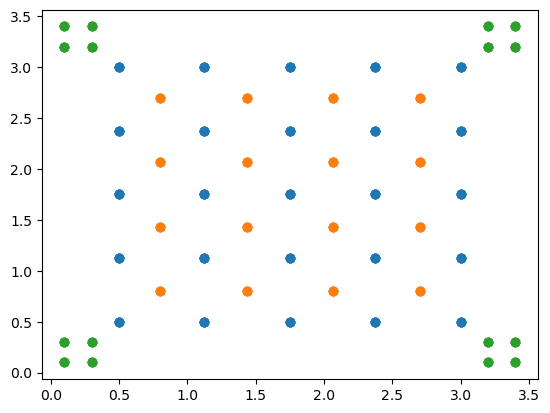

In [9]:
plt.scatter(data_train['kappa'], data_train['sigma'])
plt.scatter(data_interp['kappa'], data_interp['sigma'])
plt.scatter(data_extrap['kappa'], data_extrap['sigma'])

In [104]:
def get_train_test_split(data, n_samples, cutoff):
    temp_order = np.arange(0, n_samples, 1, dtype=int)
    random.shuffle(temp_order)
    train_k = np.array([data['kappa'][temp_order[i]] for i in range(cutoff)])
    train_q = np.array([data['q'][temp_order[i]] for i in range(cutoff)])
    train_sigma = np.array([data['sigma'][temp_order[i]] for i in range(cutoff)])
    train_e = np.array([data['E'][temp_order[i]] for i in range(cutoff)])
    val_k = np.array([data['kappa'][temp_order[i+cutoff]] for i in range(len(data)-cutoff)])
    val_q = np.array([data['q'][temp_order[i+cutoff]] for i in range(len(data)-cutoff)])
    val_sigma = np.array([data['sigma'][temp_order[i+cutoff]] for i in range(len(data)-cutoff)])
    val_e = np.array([data['E'][temp_order[i+cutoff]] for i in range(len(data)-cutoff)])
    return train_k, train_q, train_sigma, train_e, val_k, val_q, val_sigma, val_e

def mult(arr, mat):
    """
    Multiplies array with matrices
    """
    new_mats = []
    for i in arr:
        new_mats.append(i*mat)
    return np.array(new_mats)

def H_mat(n_bases, x, params):
    """
    Build matrix equation 
    
    n_bases: number of dimensions of matrices
    x: set of matrix elements

    returns: full matrix
    """
    n_params = len(params)
    H = np.zeros((n_bases,n_bases)) # Total Hamiltonian
    H_next = np.zeros((n_params, n_bases, n_bases))# symmetric matrix components of the Hamiltonian
    tmp = 0
        
    # Creating the symmetric matrix from the given matrix elements
    for k in range(n_params):
        for i in range(n_bases):
            for j in range(i, n_bases):
                H_next[k][i][j] = x[tmp]
                H_next[k][j][i] = H_next[k][i][j]
                tmp += 1
    
    # Adding the symmetric matrices to the final Hamiltonian
    counter = 0
    for i in range(n_params):
        H = H + mult(params[i,:], H_next[counter])
        counter += 1
    return H

def H_mat(n_bases, x, opt_params):
    n_bases = int(np.round(n_bases))
    num_tri = n_bases * (n_bases + 1) // 2
    
    # 1. Construct matrices from the 1D parameter array 'x'
    # First n_bases elements make up the diagonal matrix
    H_diag = np.diag(x[0:n_bases])
    
    # Next block makes up symm1
    symm1 = np.zeros((n_bases, n_bases))
    iu = np.triu_indices(n_bases)
    symm1[iu] = x[n_bases : n_bases + num_tri]
    symm1 = symm1 + symm1.T - np.diag(symm1.diagonal())
    
    # Final block makes up symm2
    symm2 = np.zeros((n_bases, n_bases))
    symm2[iu] = x[n_bases + num_tri : n_bases + 2 * num_tri]
    symm2 = symm2 + symm2.T - np.diag(symm2.diagonal())

    # 2. Extract batch variables (kappa, q, sigma)
    # Assumes opt_params is shape (3, N_samples)
    kappa = opt_params[0, :].reshape(-1, 1, 1)
    q     = opt_params[1, :].reshape(-1, 1, 1)
    sigma = opt_params[2, :].reshape(-1, 1)
    
    # 3. Calculate the matrix power: symm2^sigma
    evals, evecs = np.linalg.eigh(symm2)
    
    # SAFEGUARD: Extract sign, exponentiate absolute value, and re-apply sign.
    # This completely prevents the LinAlgError (NaNs) from fractional exponents.
    D_p = np.sign(evals) * (np.abs(evals) ** sigma)
    
    # Reconstruct the matrix batch (N_samples, n_bases, n_bases)
    symm2_pow = np.einsum('ij,kj,lj->kil', evecs, D_p, evecs)
    
    # 4. Assemble the final Hamiltonian
    # NumPy broadcasting allows us to add the 2D H_diag to the 3D batched matrices seamlessly
    H = H_diag + (kappa * symm1) + (q * symm2_pow)
    
    return H

def find_e(n_bases, x, params):
    """
    Find lowest eigenvalue
    
    Lecs: Operator LECs
    n_bases: number of dimensions of the parametric matrix model
    x: set of PMM matrix elements
    
    returns: all eigenvalues, the lowest is the energy we fit for
    """
    H = H_mat(n_bases, x, params)
    ev, ef = np.linalg.eigh(H)
    return ev


# Fit cost function
def cost_function(x, params, BE_training, n_bases, n_ev): # rms cost function
    BE_predict = find_e(n_bases, x, params)

    cost = sum((abs(np.array(BE_predict[:,n_ev])-np.array(BE_training))) ** 2)

    return cost

def cost_function(x, params, BE_training, n_bases, n_ev):
    # BE_predict will be shape (80, n_bases)
    BE_predict = find_e(n_bases, x, params)

    # Extract the specific eigenvalue column (n_ev) for all 80 samples
    predictions = BE_predict[:, n_ev]
    
    # Calculate Mean Squared Error
    errors = predictions - BE_training
    cost = np.sum(errors**2)

    return cost

# Fit PMM
def get_pmm(coeffs, solutions, n_bases, n_train, n_ev):
    """
    n_tests: array of 1 through number of test values, last number should be less than length of train_order
    n_lecs: the number of LECs that have matrices associated
    """
    n_params = len(coeffs)
    n_pred = int(n_params*n_bases*(n_bases+1)/2) # number of parameters to find in PMM
    x_temp = np.array([random.randint(-50,50) for i in range(n_pred)]) # initial guess for PMM parameters
    bounds = [(-500, 500)] * len(x_temp)
    res_da = scipy.optimize.dual_annealing(cost_function, bounds, args=(coeffs[:,:n_train], solutions[:n_train], n_bases, n_ev), x0=x_temp)
    return res_da['x'], res_da['fun']

def mean_center(data, mean):
    return data - mean

def get_square_error(df_results, dim, ev, params, e_mean, row):
    x_pmm_output = df_results[df_results['matrix_dimensions'] == dim][df_results['eigenvalue_fit'] == ev]['output_parameters']
    e_pred_interp = find_e(dim, x_pmm_output[row], params)[:, ev]
    interp_error = (e_pred_interp - e_mean)**2
    return interp_error

def get_variable_evs(df_results, q, sigma, kappa, dim, ev, row):
    params = np.array([mean_center(kappa, mean_kappa), mean_center(q, mean_q), mean_center(sigma, mean_sigma)])
    x_pmm_output = df_results[df_results['matrix_dimensions'] == dim][df_results['eigenvalue_fit'] == ev]['output_parameters']
    evs = find_e(5, x_pmm_output[row], params)
    return evs

In [11]:
n_pred = int(3*2*(2+1)/2) # number of parameters to find in PMM
x_temp = np.array([random.randint(-50,50) for i in range(n_pred)]) # initial guess for PMM parameters

In [49]:
# 1. Calculate training means for centering
mean_q = np.average(data_train['q'])
mean_kappa = np.average(data_train['kappa'])
mean_sigma = np.average(data_train['sigma'])
mean_e = np.average(data_train['E'])

# 2. Prepare centered parameter arrays for all three datasets
params_train = np.array([
    mean_center(data_train['kappa'], mean_kappa), 
    mean_center(data_train['q'], mean_q), 
    mean_center(data_train['sigma'], mean_sigma)
])
e_train_centered = mean_center(data_train['E'], mean_e)

# Prepare interpolation data (centered using TRAINING means)
params_interp = np.array([
    mean_center(data_interp['kappa'], mean_kappa), 
    mean_center(data_interp['q'], mean_q), 
    mean_center(data_interp['sigma'], mean_sigma)
])
e_interp_centered = mean_center(data_interp['E'], mean_e)

# Prepare extrapolation data (centered using TRAINING means)
params_extrap = np.array([
    mean_center(data_extrap['kappa'], mean_kappa), 
    mean_center(data_extrap['q'], mean_q), 
    mean_center(data_extrap['sigma'], mean_sigma)
])
e_extrap_centered = mean_center(data_extrap['E'], mean_e)

n_train = len(data_train) 

# Initialize list to store our dictionary rows
results = []

# 3. Loop over dimensions and eigenvalues
n_dim = range(1, 6) # e.g., 1, 2, 3, 4, 5 (0 is skipped as a 0x0 matrix is invalid)

for i in n_dim:
    for j in range(i): # j represents the eigenvalue index being fit (0 to i-1)
        
        print(f"Fitting n_bases={i}, eigenvalue={j}...")
        
        # Train the PMM model
        x_pmm_output, train_error = get_pmm(params_train, e_train_centered, i, n_train, j)
        
        # Calculate Interpolation Error (Mean Squared Error)
        # find_e returns all eigenvalues, so we slice [:, j] to get the specific one we fit
        e_pred_interp = find_e(i, x_pmm_output, params_interp)[:, j]
        interp_error = np.mean((e_pred_interp - e_interp_centered)**2)
        
        # Calculate Extrapolation Error (Mean Squared Error)
        e_pred_extrap = find_e(i, x_pmm_output, params_extrap)[:, j]
        extrap_error = np.mean((e_pred_extrap - e_extrap_centered)**2)
        
        # Store the results
        results.append({
            "output_parameters": x_pmm_output.tolist(), # Saved as a list for clean dataframe storage
            "matrix_dimensions": i,
            "eigenvalue_fit": j,
            "training_error": train_error, 
            "interpolation_error": interp_error,
            "extrapolation_error": extrap_error
        })

# 4. Convert to DataFrame
df_results = pd.DataFrame(results)

# Save or display the dataframe
df_results.to_csv("pmm_fitting_results.csv", index=False)
display(df_results)

Fitting n_bases=1, eigenvalue=0...
Fitting n_bases=2, eigenvalue=0...
Fitting n_bases=2, eigenvalue=1...
Fitting n_bases=3, eigenvalue=0...
Fitting n_bases=3, eigenvalue=1...
Fitting n_bases=3, eigenvalue=2...
Fitting n_bases=4, eigenvalue=0...
Fitting n_bases=4, eigenvalue=1...
Fitting n_bases=4, eigenvalue=2...
Fitting n_bases=4, eigenvalue=3...
Fitting n_bases=5, eigenvalue=0...
Fitting n_bases=5, eigenvalue=1...
Fitting n_bases=5, eigenvalue=2...
Fitting n_bases=5, eigenvalue=3...
Fitting n_bases=5, eigenvalue=4...


,output_parameters,matrix_dimensions,eigenvalue_fit,training_error,interpolation_error,extrapolation_error
0,"[-1.4479550870968275e-06, 0.39786065261084863,...",1,0,115.716811,0.602136,2.011542
1,"[0.0819663776998731, 87.68794462361453, 0.3727...",2,0,0.256561,0.000642,0.086135
2,"[-129.55960366806775, -0.034259490430603626, -...",2,1,1.125274,0.005022,0.116005
3,"[0.08420825499478062, 482.28327793191255, 58.2...",3,0,0.211749,0.000680,70.517544
4,"[-373.4282244453249, 0.045010214487413935, 414...",3,1,0.374549,0.000915,84.317943
5,"[-497.28538133029804, -0.035030408502823684, -...",3,2,1.110756,0.005108,444.349892
6,"[0.06423878234483972, 333.0189846269031, 275.4...",4,0,0.164613,0.001345,2136.615352
7,"[-55.46781543771705, 269.23600451186877, 0.065...",4,1,0.348159,0.059220,0.047814
8,"[41.677598274663865, 0.030594296872391253, -18...",4,2,0.883934,0.509245,0.108090
9,"[-61.46254414137199, -0.04402796466526041, -45...",4,3,0.976565,0.004905,51.424860


### Plotting

C:\Users\armstroc\AppData\Local\Temp\ipykernel_19388\3453847674.py:146: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_pmm_output = df_results[df_results['matrix_dimensions'] == dim][df_results['eigenvalue_fit'] == ev]['output_parameters']
C:\Users\armstroc\AppData\Local\Temp\ipykernel_19388\3453847674.py:146: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_pmm_output = df_results[df_results['matrix_dimensions'] == dim][df_results['eigenvalue_fit'] == ev]['output_parameters']
C:\Users\armstroc\AppData\Local\Temp\ipykernel_19388\3453847674.py:146: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_pmm_output = df_results[df_results['matrix_dimensions'] == dim][df_results['eigenvalue_fit'] == ev]['output_parameters']
C:\Users\armstroc\AppData\Local\Temp\ipykernel_19388\3453847674.py:146: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_pmm_output = df_results[df_re

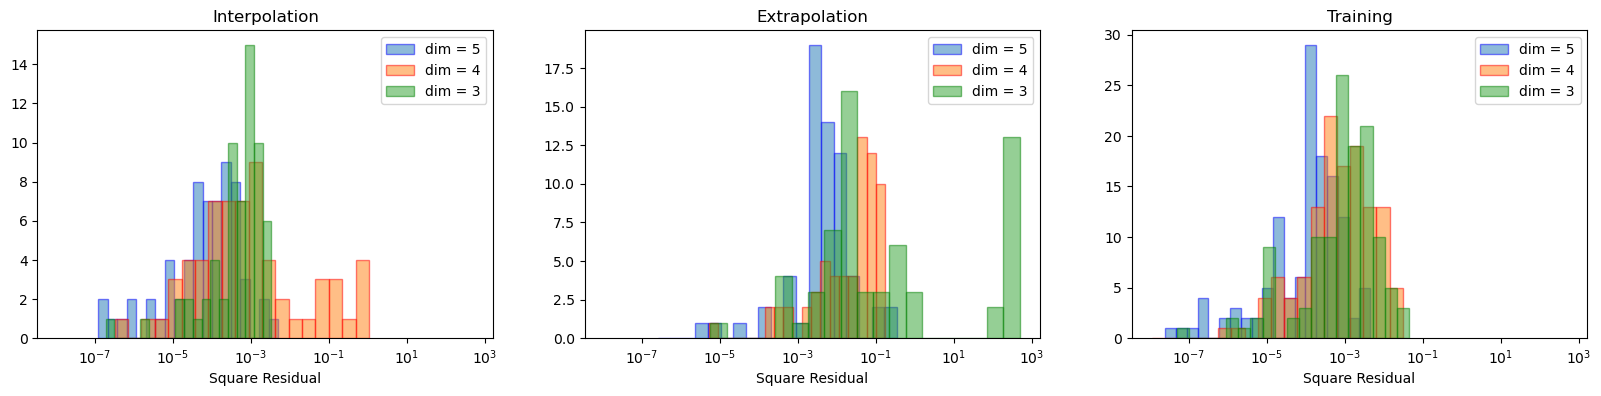

In [97]:
interp_error5 = get_square_error(df_results, 5, 1, params_interp, e_interp_centered, 11)
extrap_error5 = get_square_error(df_results, 5, 1, params_extrap, e_extrap_centered, 11)
train_error5 = get_square_error(df_results, 5, 1, params_train, e_train_centered, 11)
interp_error4 = get_square_error(df_results, 4, 1, params_interp, e_interp_centered, 7)
extrap_error4 = get_square_error(df_results, 4, 1, params_extrap, e_extrap_centered, 7)
train_error4 = get_square_error(df_results, 4, 1, params_train, e_train_centered, 7)
interp_error3 = get_square_error(df_results, 3, 1, params_interp, e_interp_centered, 4)
extrap_error3 = get_square_error(df_results, 3, 1, params_extrap, e_extrap_centered, 4)
train_error3 = get_square_error(df_results, 3, 1, params_train, e_train_centered, 4)
# interp_error2 = get_square_error(df_results, 2, 1, params_interp, e_interp_centered, 2)
# extrap_error2 = get_square_error(df_results, 2, 1, params_extrap, e_extrap_centered, 2)

fig, axs = plt.subplots(1, 3, sharex=True, figsize=(20,4))

axs[0].hist(interp_error5, bins=np.logspace(np.log10(min(interp_error5)),np.log10(max(interp_error5)), 20), edgecolor='blue', alpha=0.5, label='dim = 5')
axs[0].hist(interp_error4, bins=np.logspace(np.log10(min(interp_error4)),np.log10(max(interp_error4)), 20), edgecolor='red', alpha=0.5, label='dim = 4')
axs[0].hist(interp_error3, bins=np.logspace(np.log10(min(interp_error3)),np.log10(max(interp_error3)), 20), edgecolor='green', alpha=0.5, label='dim = 3')

axs[1].hist(extrap_error5, bins=np.logspace(np.log10(min(extrap_error5)),np.log10(max(extrap_error5)), 20), edgecolor='blue', alpha=0.5, label='dim = 5')
axs[1].hist(extrap_error4, bins=np.logspace(np.log10(min(extrap_error4)),np.log10(max(extrap_error4)), 20), edgecolor='red', alpha=0.5, label='dim = 4')
axs[1].hist(extrap_error3, bins=np.logspace(np.log10(min(extrap_error3)),np.log10(max(extrap_error3)), 20), edgecolor='green', alpha=0.5, label='dim = 3')

axs[2].hist(train_error5, bins=np.logspace(np.log10(min(train_error5)),np.log10(max(train_error5)), 20), edgecolor='blue', alpha=0.5, label='dim = 5')
axs[2].hist(train_error4, bins=np.logspace(np.log10(min(train_error4)),np.log10(max(train_error4)), 20), edgecolor='red', alpha=0.5, label='dim = 4')
axs[2].hist(train_error3, bins=np.logspace(np.log10(min(train_error3)),np.log10(max(train_error3)), 20), edgecolor='green', alpha=0.5, label='dim = 3')

plt.xscale('log')

axs[0].set_xlabel('Square Residual')
axs[0].set_title('Interpolation')
axs[0].legend()

axs[1].set_xlabel('Square Residual')
axs[1].set_title('Extrapolation')
axs[1].legend()

axs[2].set_xlabel('Square Residual')
axs[2].set_title('Training')
axs[2].legend()
plt.show()

In [173]:
n_points = 200
q_fixed = np.ones(n_points)
sigma_fixed = 1.75*np.ones(n_points)
kappa_fixed = 1.75*np.ones(n_points)
q = np.linspace(-2.0, 2.0, n_points)
sigma = np.linspace(0.5, 3.0, n_points)
kappa = np.linspace(0.5, 3.0, n_points)
q_diff = np.array([-2, -1, 0, 1, 2])
kappa_diff = np.linspace(0.5, 3, 5)
sigma_diff = np.linspace(0.5, 3, 5)

variable_q_static_sigma = []
for i in range(len(q_diff)):
    variable_q_static_sigma.append(get_variable_evs(df_results, q_diff[i]*np.ones(n_points), sigma_fixed, kappa, 5, 1, 11)) # sigma=1.75

variable_kappa_static_sigma = []
for i in range(len(kappa_diff)):
    variable_kappa_static_sigma.append(get_variable_evs(df_results, q, sigma_fixed, kappa_diff[i]*np.ones(n_points), 5, 1, 11)) # sigma=1.75

variable_sigma_static_q = []
for i in range(len(kappa_diff)):
    variable_sigma_static_q.append(get_variable_evs(df_results, q_fixed, sigma, kappa_diff[i]*np.ones(n_points), 5, 1, 11)) # q=1

variable_kappa_static_q = []
for i in range(len(sigma_diff)):
    variable_kappa_static_q.append(get_variable_evs(df_results, q_fixed, sigma_diff[i]*np.ones(n_points), kappa, 5, 1, 11)) # q=1

variable_q_static_kappa = []
for i in range(len(kappa_diff)):
    variable_q_static_kappa.append(get_variable_evs(df_results, q, sigma_diff[i]*np.ones(n_points), kappa_fixed, 5, 1, 11)) # kappa=1.75

variable_sigma_static_kappa = []
for i in range(len(q_diff)):
    variable_sigma_static_kappa.append(get_variable_evs(df_results, q_diff[i]*np.ones(n_points), sigma, kappa_fixed, 5, 1, 11)) # kappa=1.75


C:\Users\armstroc\AppData\Local\Temp\ipykernel_19388\4242350800.py:153: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_pmm_output = df_results[df_results['matrix_dimensions'] == dim][df_results['eigenvalue_fit'] == ev]['output_parameters']
C:\Users\armstroc\AppData\Local\Temp\ipykernel_19388\4242350800.py:153: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_pmm_output = df_results[df_results['matrix_dimensions'] == dim][df_results['eigenvalue_fit'] == ev]['output_parameters']
C:\Users\armstroc\AppData\Local\Temp\ipykernel_19388\4242350800.py:153: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_pmm_output = df_results[df_results['matrix_dimensions'] == dim][df_results['eigenvalue_fit'] == ev]['output_parameters']
C:\Users\armstroc\AppData\Local\Temp\ipykernel_19388\4242350800.py:153: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_pmm_output = df_results[df_re

<>:6: SyntaxWarning: invalid escape sequence '\k'
<>:13: SyntaxWarning: invalid escape sequence '\k'
<>:24: SyntaxWarning: invalid escape sequence '\k'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\k'
<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:57: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\k'
<>:13: SyntaxWarning: invalid escape sequence '\k'
<>:24: SyntaxWarning: invalid escape sequence '\k'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\k'
<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:57: SyntaxWarning: invalid escape sequence '\s'
C:\Users\armstroc\AppData\Local\Temp\ipykernel_19388\2461432724.py:6: SyntaxWarning: invalid escape sequence '\k'
  plt.xlabel('$\kappa$')
C:\Users\armstroc\AppData\Local\Temp\ipykernel_

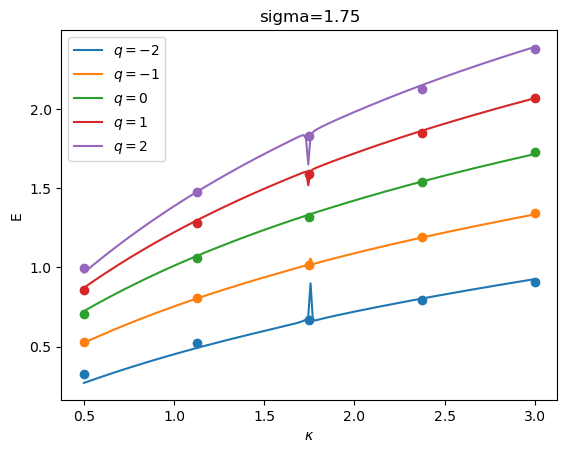

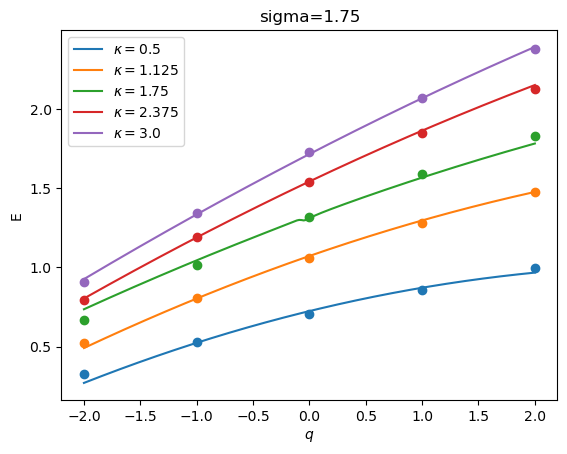

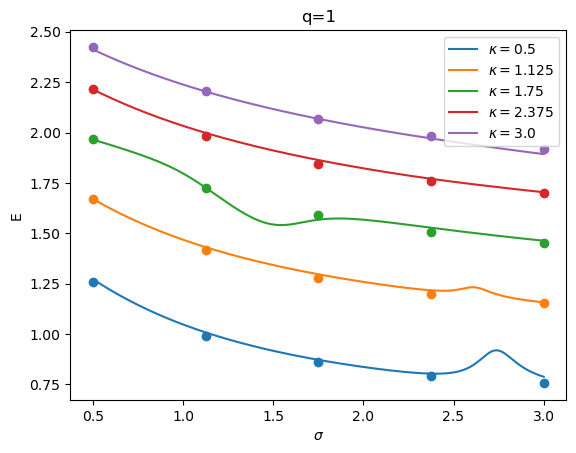

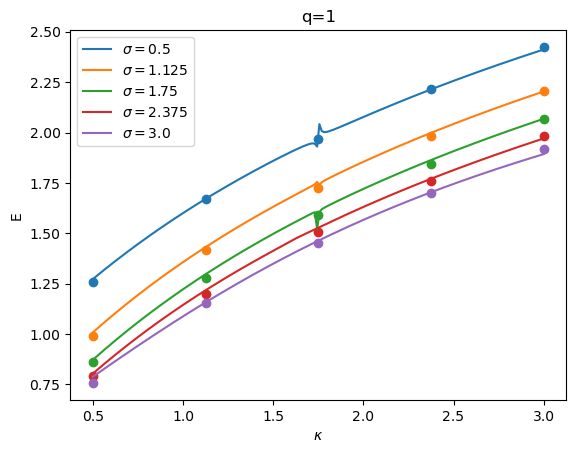

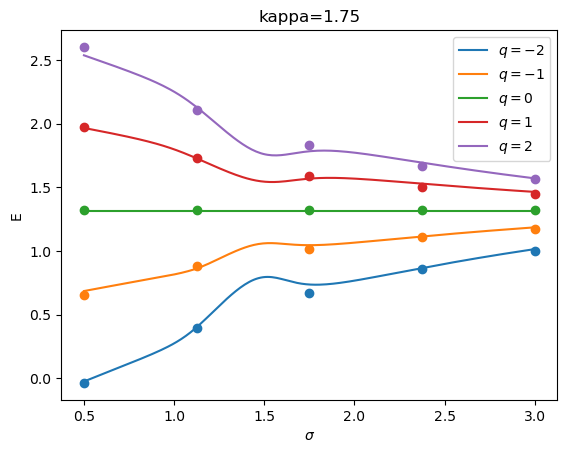

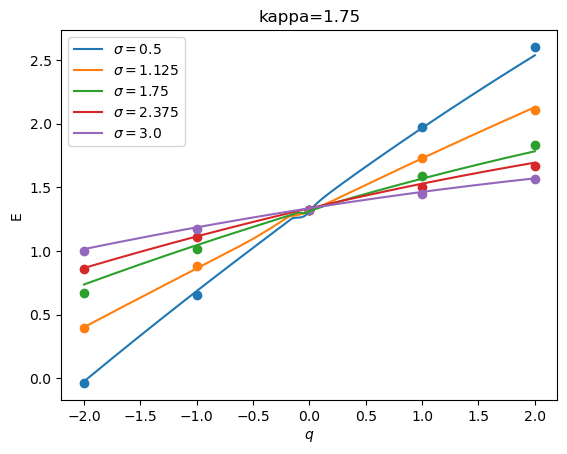

In [174]:
for i in range(len(variable_q_static_sigma)):
    mask = (data_train['sigma'] == 1.75) & (data_train['q'] == q_diff[i])
    plt.plot(kappa, variable_q_static_sigma[i][:,1]+mean_e, label=f'$q={q_diff[i]}$')
    plt.scatter(data_train['kappa'][mask], data_train['E'][mask])
plt.title('sigma=1.75')
plt.xlabel('$\kappa$')
plt.ylabel('E')
plt.legend()
plt.savefig('figures/vary_kappa_static_sigma.png')
plt.show()

for i in range(len(variable_kappa_static_sigma)):
    plt.plot(q, variable_kappa_static_sigma[i][:,1]+mean_e, label=f'$\kappa={kappa_diff[i]}$')
    mask = (data_train['sigma'] == 1.75) & (data_train['kappa'] == kappa_diff[i])
    plt.scatter(data_train['q'][mask], data_train['E'][mask])
plt.title('sigma=1.75')
plt.xlabel('$q$')
plt.ylabel('E')
plt.legend()
plt.savefig('figures/vary_q_static_sigma.png')
plt.show()

for i in range(len(variable_sigma_static_q)):
    plt.plot(sigma, variable_sigma_static_q[i][:,1]+mean_e, label=f'$\kappa={kappa_diff[i]}$')
    mask = (data_train['q'] == 1.0) & (data_train['kappa'] == kappa_diff[i])
    plt.scatter(data_train['sigma'][mask], data_train['E'][mask])
plt.title('q=1')
plt.xlabel('$\sigma$')
plt.ylabel('E')
plt.legend()
plt.savefig('figures/vary_sigma_static_q.png')
plt.show()

for i in range(len(variable_kappa_static_q)):
    plt.plot(kappa, variable_kappa_static_q[i][:,1]+mean_e, label=f'$\sigma={sigma_diff[i]}$')
    mask = (data_train['q'] == 1.0) & (data_train['sigma'] == sigma_diff[i])
    plt.scatter(data_train['kappa'][mask], data_train['E'][mask])
plt.title('q=1')
plt.xlabel('$\kappa$')
plt.ylabel('E')
plt.legend()
plt.savefig('figures/vary_kappa_static_q.png')
plt.show()

for i in range(len(variable_sigma_static_kappa)):
    plt.plot(sigma, variable_sigma_static_kappa[i][:,1]+mean_e, label=f'$q={q_diff[i]}$')
    mask = (data_train['kappa'] == 1.75) & (data_train['q'] == q_diff[i])
    plt.scatter(data_train['sigma'][mask], data_train['E'][mask])
plt.title('kappa=1.75')
plt.xlabel('$\sigma$')
plt.ylabel('E')
plt.legend()
plt.savefig('figures/vary_sigma_static_kappa.png')
plt.show()

for i in range(len(variable_q_static_kappa)):
    plt.plot(q, variable_q_static_kappa[i][:,1]+mean_e, label=f'$\sigma={sigma_diff[i]}$')
    mask = (data_train['kappa'] == 1.75) & (data_train['sigma'] == sigma_diff[i])
    plt.scatter(data_train['q'][mask], data_train['E'][mask])
plt.title('kappa=1.75')
plt.xlabel('$q$')
plt.ylabel('E')
plt.legend()
plt.savefig('figures/vary_q_static_kappa.png')
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\k'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\k'
<>:30: SyntaxWarning: invalid escape sequence '\k'
<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\k'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\k'
<>:30: SyntaxWarning: invalid escape sequence '\k'
<>:31: SyntaxWarning: invalid escape sequence '\s'
C:\Users\armstroc\AppData\Local\Temp\ipykernel_19388\4226142058.py:10: SyntaxWarning: invalid escape sequence '\k'
  plt.xlabel('$\kappa$')
C:\Users\armstroc\AppData\Local\Temp\ipykernel_19388\4226142058.py:12: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'$\sigma={np.unique(params_interp[2])[i]}$')
C:\Users\armstroc\AppData\Local\Temp\ipykernel_19388\4226142058.py:21: Synt

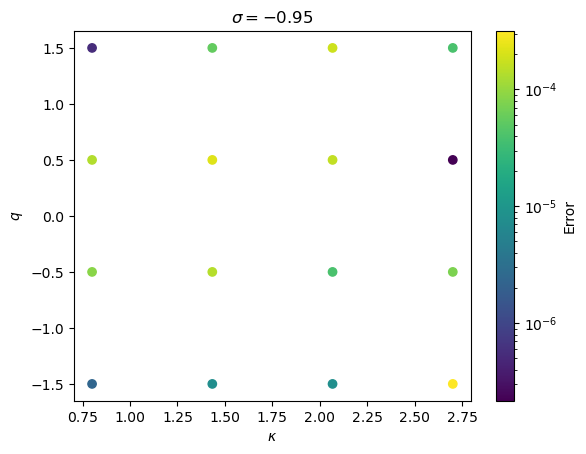

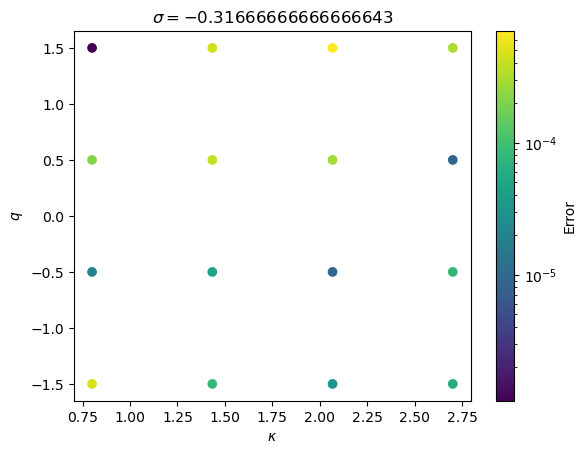

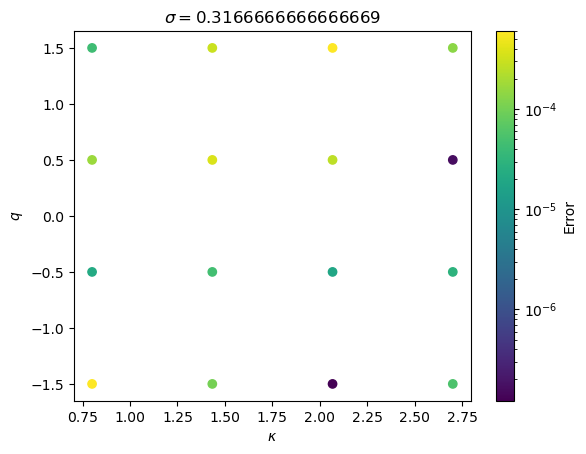

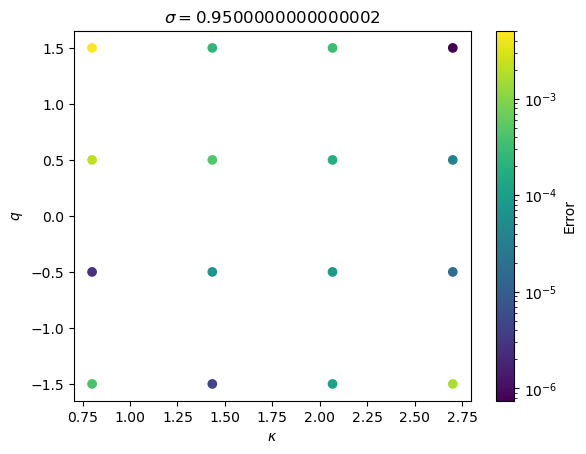

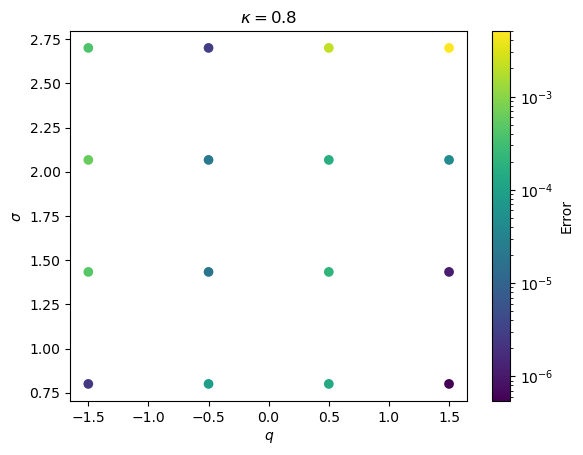

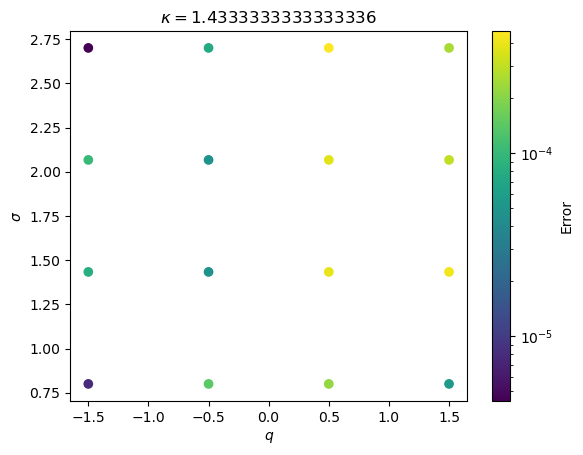

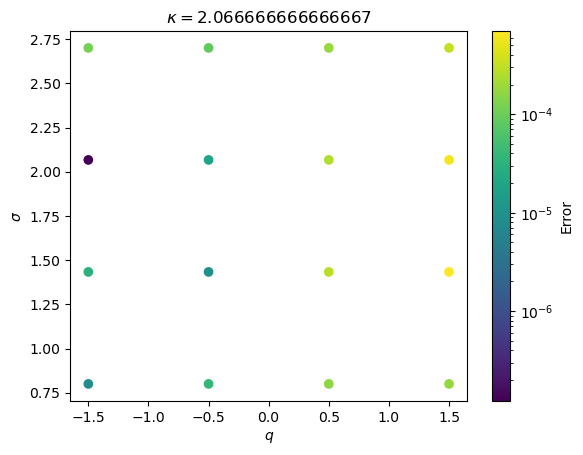

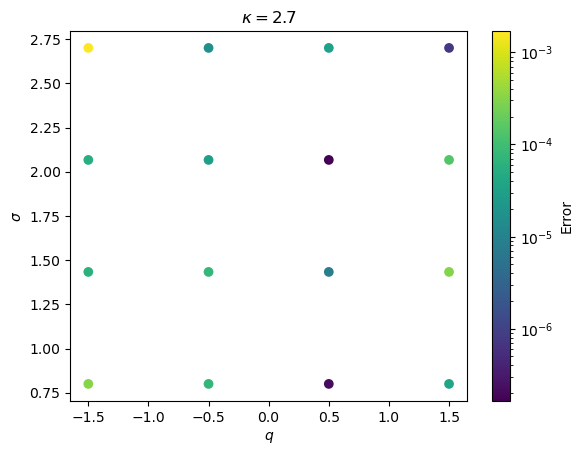

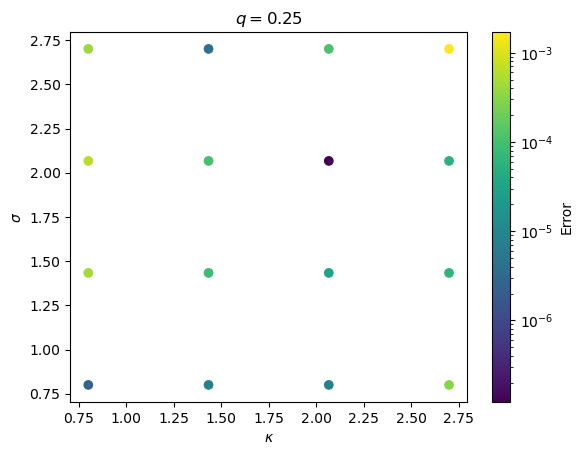

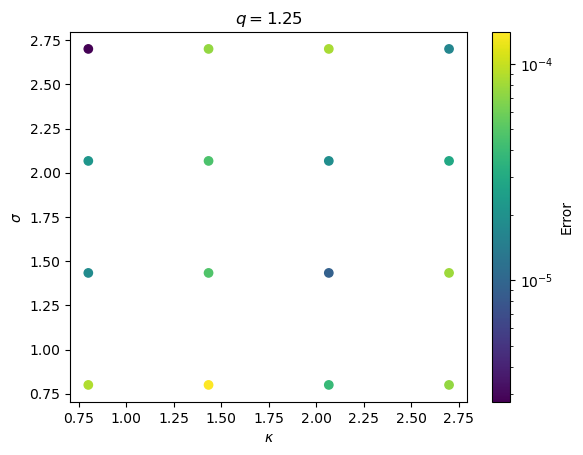

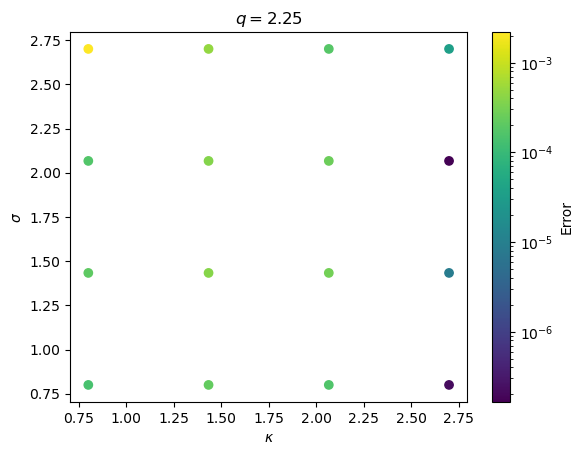

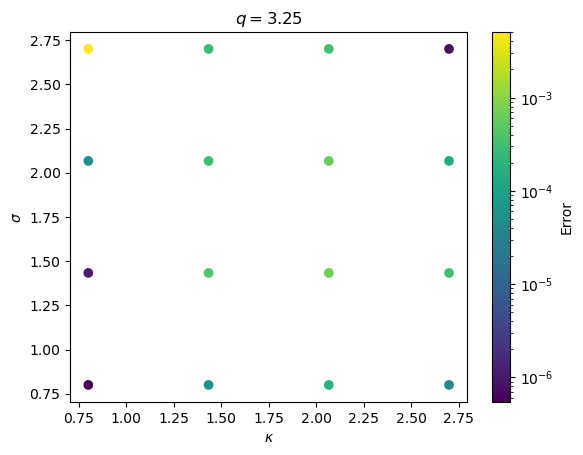

In [195]:
interp_error5
params_interp # kappa, q, sigma
colors = interp_error5.array # The values used for color mapping

# Create a scatter plot and apply the 'viridis' colormap
for i in range(len(np.unique(params_interp[2]))):
    mask = params_interp[2] == np.unique(params_interp[2])[i]
    plt.scatter(params_interp[0][mask]+mean_kappa, params_interp[1][mask]+mean_q, c=interp_error5[mask].array, cmap='viridis', norm=LogNorm())
    plt.colorbar(label='Error')
    plt.xlabel('$\kappa$')
    plt.ylabel('$q$')
    plt.title(f'$\sigma={np.unique(params_interp[2])[i]}$')
    plt.savefig(f'figures/interp_error_sigma_{np.unique(params_interp[2])[i]:.2f}.png')
    plt.show()

for i in range(len(np.unique(params_interp[0]))):
    mask = params_interp[0] == np.unique(params_interp[0])[i]
    plt.scatter(params_interp[1][mask]+mean_q, params_interp[2][mask]+mean_sigma, c=interp_error5[mask].array, cmap='viridis', norm=LogNorm())
    plt.colorbar(label='Error')
    plt.xlabel('$q$')
    plt.ylabel('$\sigma$')
    plt.title(f'$\kappa={np.unique(params_interp[0])[i]+mean_kappa}$')
    plt.savefig(f'figures/interp_error_kappa_{np.unique(params_interp[0])[i]+mean_kappa:.2f}.png')
    plt.show()

for i in range(len(np.unique(params_interp[1]))):
    mask = params_interp[1] == np.unique(params_interp[1])[i]
    plt.scatter(params_interp[0][mask]+mean_kappa, params_interp[2][mask]+mean_sigma, c=interp_error5[mask].array, cmap='viridis', norm=LogNorm())
    plt.colorbar(label='Error')
    plt.xlabel('$\kappa$')
    plt.ylabel('$\sigma$')
    plt.title(f'$q={np.unique(params_interp[1])[i]+mean_sigma}$')
    plt.savefig(f'figures/interp_error_q_{np.unique(params_interp[1])[i]+mean_sigma:.2f}.png')
    plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\k'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\k'
<>:26: SyntaxWarning: invalid escape sequence '\k'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\k'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\k'
<>:26: SyntaxWarning: invalid escape sequence '\k'
<>:27: SyntaxWarning: invalid escape sequence '\s'
C:\Users\armstroc\AppData\Local\Temp\ipykernel_19388\1194084959.py:6: SyntaxWarning: invalid escape sequence '\k'
  plt.xlabel('$\kappa$')
C:\Users\armstroc\AppData\Local\Temp\ipykernel_19388\1194084959.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'$\sigma={np.unique(params_extrap[2])[i]}$')
C:\Users\armstroc\AppData\Local\Temp\ipykernel_19388\1194084959.py:17: SyntaxWarn

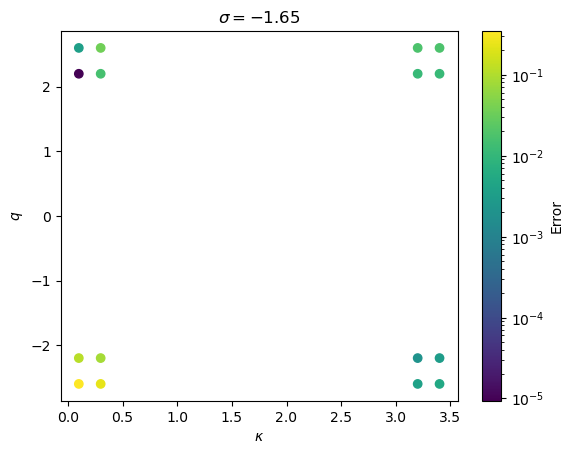

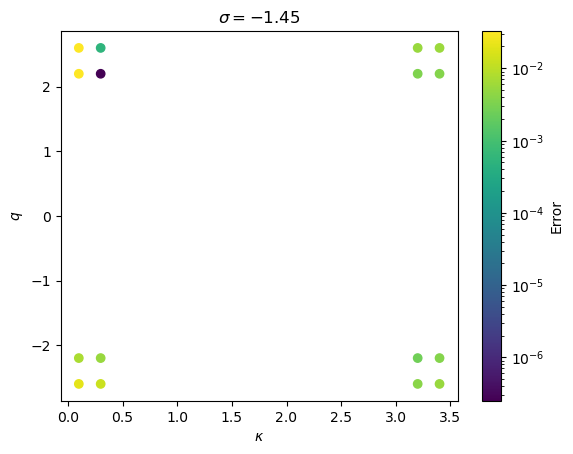

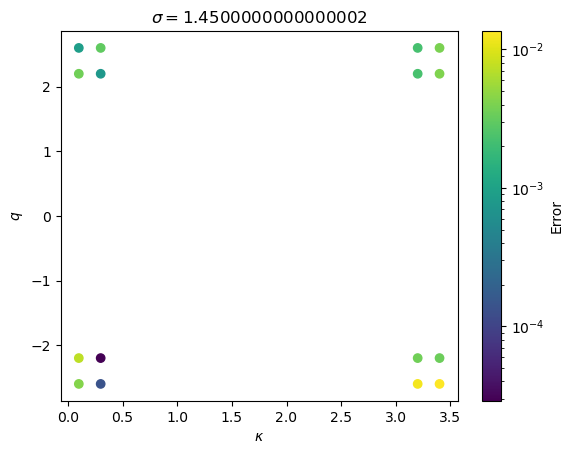

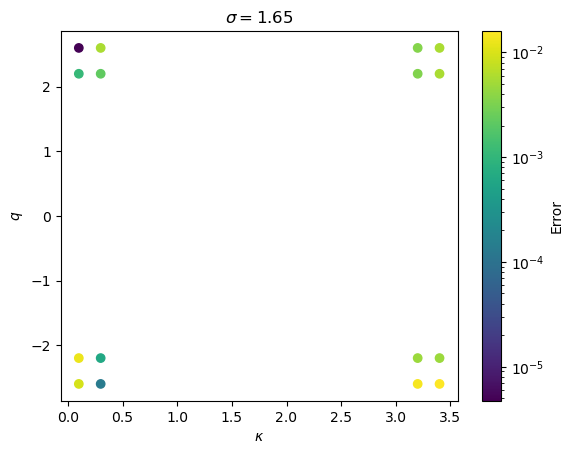

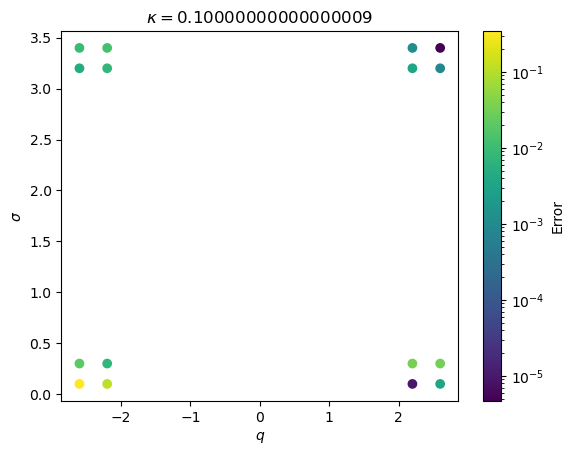

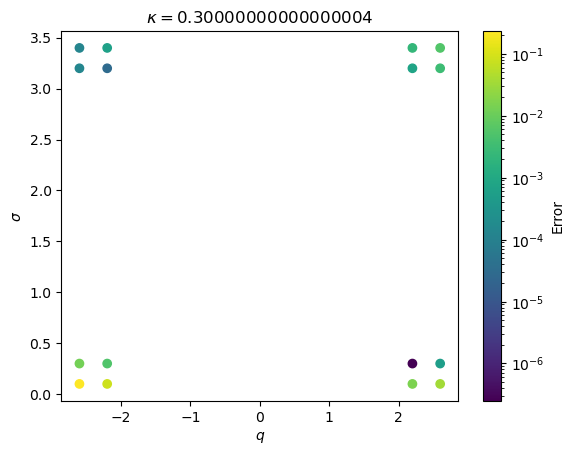

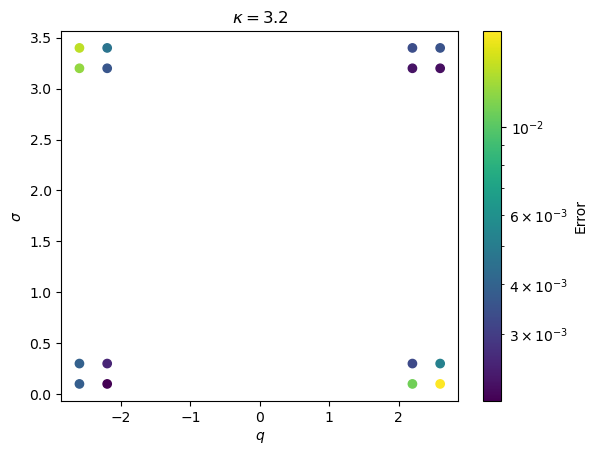

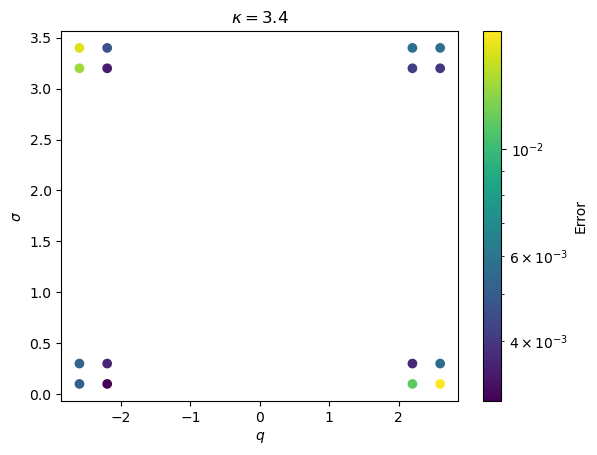

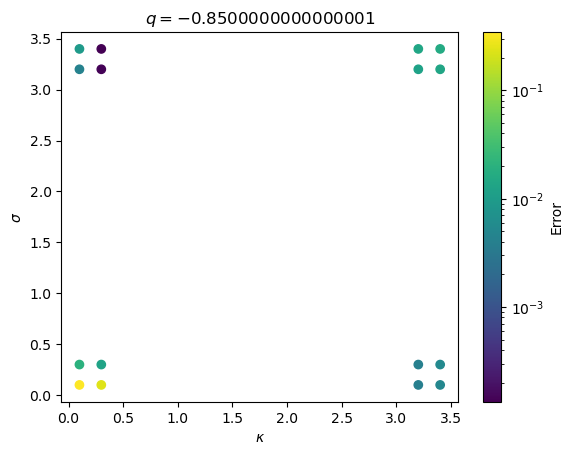

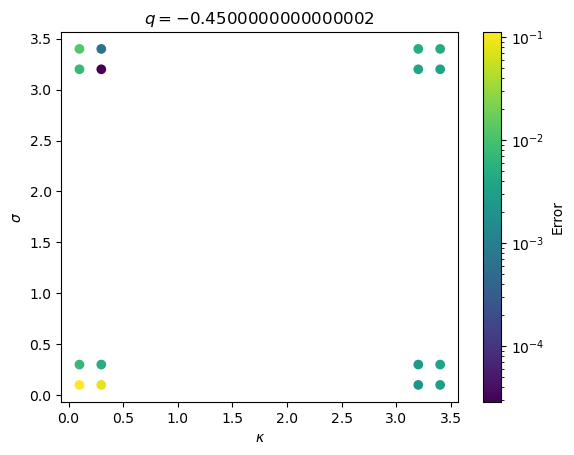

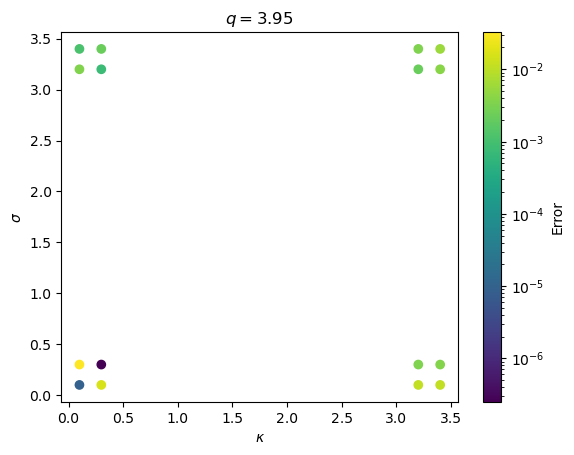

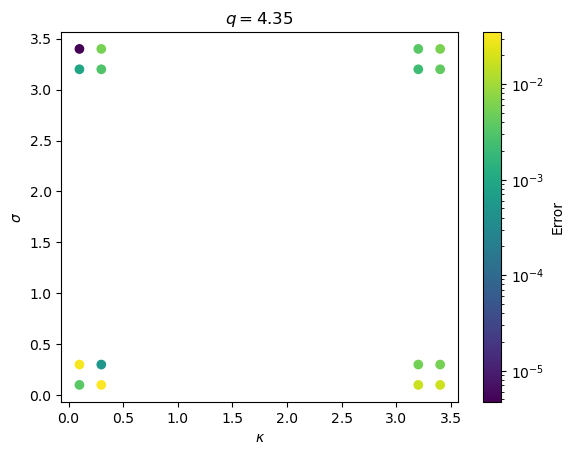

In [196]:
# Create a scatter plot and apply the 'viridis' colormap
for i in range(len(np.unique(params_extrap[2]))):
    mask = params_extrap[2] == np.unique(params_extrap[2])[i]
    plt.scatter(params_extrap[0][mask]+mean_kappa, params_extrap[1][mask]+mean_q, c=extrap_error5[mask].array, cmap='viridis', norm=LogNorm())
    plt.colorbar(label='Error')
    plt.xlabel('$\kappa$')
    plt.ylabel('$q$')
    plt.title(f'$\sigma={np.unique(params_extrap[2])[i]}$')
    plt.savefig(f'figures/extrap_error_sigma_{np.unique(params_extrap[2])[i]:.2f}.png')
    plt.show()

for i in range(len(np.unique(params_extrap[0]))):
    mask = params_extrap[0] == np.unique(params_extrap[0])[i]
    plt.scatter(params_extrap[1][mask]+mean_q, params_extrap[2][mask]+mean_sigma, c=extrap_error5[mask].array, cmap='viridis', norm=LogNorm())
    plt.colorbar(label='Error')
    plt.xlabel('$q$')
    plt.ylabel('$\sigma$')
    plt.title(f'$\kappa={np.unique(params_extrap[0])[i]+mean_kappa}$')
    plt.savefig(f'figures/extrap_error_kappa_{np.unique(params_extrap[0])[i]+mean_kappa:.2f}.png')
    plt.show()

for i in range(len(np.unique(params_extrap[1]))):
    mask = params_extrap[1] == np.unique(params_extrap[1])[i]
    plt.scatter(params_extrap[0][mask]+mean_kappa, params_extrap[2][mask]+mean_sigma, c=extrap_error5[mask].array, cmap='viridis', norm=LogNorm())
    plt.colorbar(label='Error')
    plt.xlabel('$\kappa$')
    plt.ylabel('$\sigma$')
    plt.title(f'$q={np.unique(params_extrap[1])[i]+mean_sigma}$')
    plt.savefig(f'figures/extrap_error_q_{np.unique(params_extrap[1])[i]+mean_sigma:.2f}.png')
    plt.show()

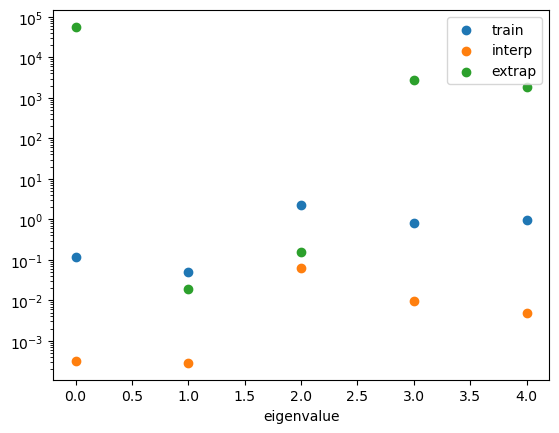

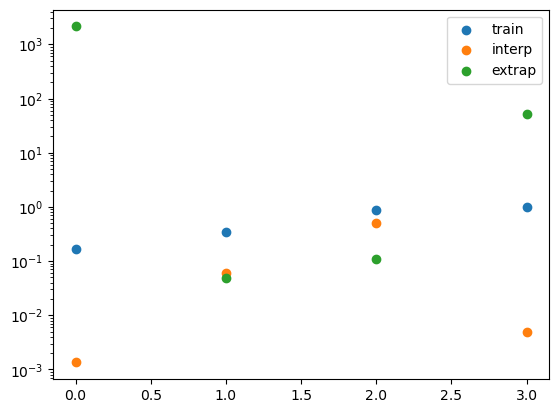

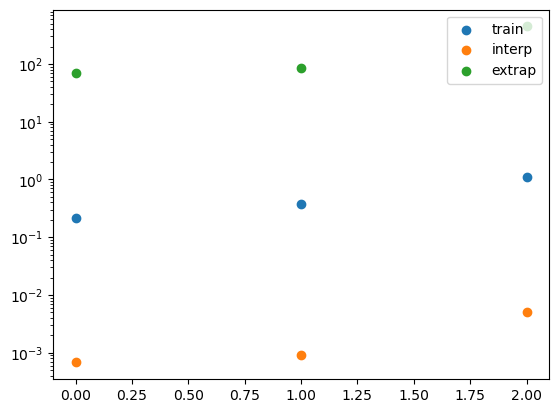

In [ ]:
plt.scatter(df_results[df_results['matrix_dimensions'] == 5]['eigenvalue_fit'], df_results[df_results['matrix_dimensions'] == 5]['training_error'], label='train')
plt.scatter(df_results[df_results['matrix_dimensions'] == 5]['eigenvalue_fit'], df_results[df_results['matrix_dimensions'] == 5]['interpolation_error'], label='interp')
plt.scatter(df_results[df_results['matrix_dimensions'] == 5]['eigenvalue_fit'], df_results[df_results['matrix_dimensions'] == 5]['extrapolation_error'], label='extrap')
plt.yscale('log')
plt.xlabel('eigenvalue')
plt.legend()
plt.show()

plt.scatter(df_results[df_results['matrix_dimensions'] == 4]['eigenvalue_fit'], df_results[df_results['matrix_dimensions'] == 4]['training_error'], label='train')
plt.scatter(df_results[df_results['matrix_dimensions'] == 4]['eigenvalue_fit'], df_results[df_results['matrix_dimensions'] == 4]['interpolation_error'], label='interp')
plt.scatter(df_results[df_results['matrix_dimensions'] == 4]['eigenvalue_fit'], df_results[df_results['matrix_dimensions'] == 4]['extrapolation_error'], label='extrap')
plt.yscale('log')
plt.xlabel('eigenvalue')
plt.legend()
plt.show()

plt.scatter(df_results[df_results['matrix_dimensions'] == 3]['eigenvalue_fit'], df_results[df_results['matrix_dimensions'] == 3]['training_error'], label='train')
plt.scatter(df_results[df_results['matrix_dimensions'] == 3]['eigenvalue_fit'], df_results[df_results['matrix_dimensions'] == 3]['interpolation_error'], label='interp')
plt.scatter(df_results[df_results['matrix_dimensions'] == 3]['eigenvalue_fit'], df_results[df_results['matrix_dimensions'] == 3]['extrapolation_error'], label='extrap')
plt.yscale('log')
plt.xlabel('eigenvalue')
plt.legend()
plt.show()